# 04 - Observational Quasi-Experiment, Contact Cap

**Day 4, part 2, analysis.** We have no randomized cap test, so we build the closest observational proxy and analyse it in experimental framing, while being **explicit that it is not randomized**.

- **Treatment** = clients who received **1-3 contacts** this campaign (the proposed cap).
- **Control** = clients who received **4+ contacts** (uncapped behaviour).

> **These groups are observational, not randomized.** Clients were not assigned to a contact count, it emerged from how the campaign actually unfolded. Everything below is built to show *why* the naive comparison cannot be read as the causal effect of a cap.

In [1]:
# Day 4 setup: BigQuery (service account), figures, and statistics helpers.
# Every number is queried live from the marts, never a local CSV.
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from google.cloud import bigquery
from google.oauth2 import service_account

sns.set_theme(style="whitegrid", context="talk")

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
KEYFILE = REPO / "credentials" / "service-account.json"
FIG_DIR = REPO / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

PROJECT = json.loads(KEYFILE.read_text())["project_id"]
CREDS = service_account.Credentials.from_service_account_file(str(KEYFILE))
client = bigquery.Client(project=PROJECT, credentials=CREDS, location="US")
MARTS = f"{PROJECT}.marts"


def save(fig, name):
    """Write a figure to reports/figures/ at print resolution."""
    path = FIG_DIR / name
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"saved -> {path.relative_to(REPO)}")


def wilson_ci(k, n, conf=0.95):
    """Wilson score interval for a binomial proportion (better than normal
    approx at the tails). k successes out of n.
        centre = (p + z^2/2n) / (1 + z^2/n)
        half   = z/(1+z^2/n) * sqrt( p(1-p)/n + z^2/4n^2 )
    """
    z = stats.norm.ppf(1 - (1 - conf) / 2)
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = (z / denom) * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))
    return centre - half, centre + half


def two_prop_ztest(k1, n1, k2, n2):
    """Pooled two-proportion z-test (scipy supplies the normal CDF only).
        p_pool = (k1+k2)/(n1+n2)
        SE     = sqrt( p_pool(1-p_pool)(1/n1 + 1/n2) )
        z      = (p1 - p2) / SE
    Returns (p1, p2, z, two_sided_p).
    """
    p1, p2 = k1 / n1, k2 / n2
    p_pool = (k1 + k2) / (n1 + n2)
    se = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
    z = (p1 - p2) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return p1, p2, z, p_value


def pct(v, _=None):
    return f"{v:.0%}"


print(f"project={PROJECT}  connected.")


project=bank-campaign-causal  connected.


## Naive group comparison (Treatment 1-3 vs Control 4+)

In [2]:
# Build the two observational groups straight from the mart.
grp = client.query(f"""
    select case when n_contacts_this_campaign <= 3 then 'Treatment (1-3)'
                else 'Control (4+)' end as arm,
           count(*) as n,
           countif(subscribed) as subscribers,
           sum(n_contacts_this_campaign) as total_contacts
    from `{MARTS}.mart_campaign_outcomes`
    group by arm
""").to_dataframe().set_index("arm")

T = grp.loc["Treatment (1-3)"]
C = grp.loc["Control (4+)"]
kt, nt = int(T["subscribers"]), int(T["n"])
kc, nc = int(C["subscribers"]), int(C["n"])

# Two-proportion z-test (formula written out in the helper).
pt, pc, z, pval = two_prop_ztest(kt, nt, kc, nc)
lo_t, hi_t = wilson_ci(kt, nt)
lo_c, hi_c = wilson_ci(kc, nc)
abs_lift = pt - pc
rel_lift = abs_lift / pc

summary = pd.DataFrame({
    "n": [nt, nc],
    "subscribers": [kt, kc],
    "sub_rate": [pt, pc],
    "wilson_95_low": [lo_t, lo_c],
    "wilson_95_high": [hi_t, hi_c],
}, index=["Treatment (1-3)", "Control (4+)"])
display(summary.style.format({"n": "{:,}", "subscribers": "{:,}",
        "sub_rate": "{:.2%}", "wilson_95_low": "{:.2%}", "wilson_95_high": "{:.2%}"}))

print(f"absolute lift = {abs_lift*100:+.2f} pp   relative lift = {rel_lift:+.1%}")
print(f"two-proportion z = {z:.2f},  p = {pval:.2e}")

C:\Users\PRASHANT\bank-campaign-causal-intelligence\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,n,subscribers,sub_rate,wilson_95_low,wilson_95_high
Treatment (1-3),"33,553","4,085",12.17%,11.83%,12.53%
Control (4+),"7,635",555,7.27%,6.71%,7.87%


absolute lift = +4.91 pp   relative lift = +67.5%
two-proportion z = 12.24,  p = 0.00e+00


saved -> reports\figures\quasi_group_subscription_rates.png


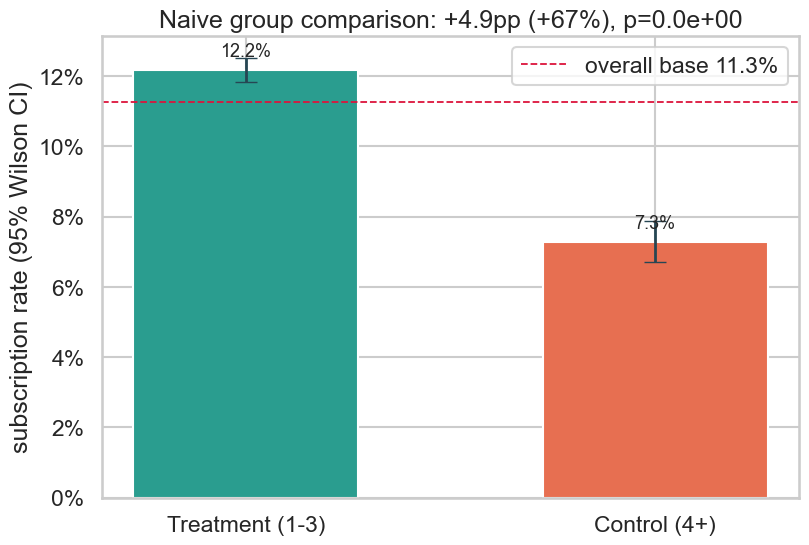

In [3]:
fig, ax = plt.subplots(figsize=(9, 6))
arms = ["Treatment (1-3)", "Control (4+)"]
rates = [pt, pc]
errs = [[pt - lo_t, pc - lo_c], [hi_t - pt, hi_c - pc]]
bars = ax.bar(arms, rates, color=["#2a9d8f", "#e76f51"], width=0.55)
ax.errorbar(arms, rates, yerr=errs, fmt="none", ecolor="#264653", capsize=8, linewidth=2)
ax.axhline(0.1127, color="crimson", linestyle="--", linewidth=1.3,
           label="overall base 11.3%")  # 11.3% base established in notebooks 01-02
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct))
for b, r in zip(bars, rates):
    ax.text(b.get_x() + b.get_width() / 2, r + 0.004, f"{r:.1%}", ha="center", fontsize=13)
ax.set_ylabel("subscription rate (95% Wilson CI)")
ax.set_title(f"Naive group comparison: {abs_lift*100:+.1f}pp ({rel_lift:+.0%}), p={pval:.1e}")
ax.legend()
save(fig, "quasi_group_subscription_rates.png")
plt.show()

_Caption: the naive read is large, the capped-range group subscribes at **12.2% vs 7.3%**, a **+4.9pp / +67% lift**, with the Wilson intervals miles apart and p essentially zero. If this were a randomized test we would ship the cap tomorrow. It is **not** randomized, the next cells show why that number is an artifact._

## SRM-style exchangeability check

In a real A/B test a **Sample Ratio Mismatch** check confirms randomization produced balanced arms. Here there was no randomization, so we run the analogous test on **covariate balance**: are the demographic distributions the same across the two groups? We chi-square each of **job, education, marital**, and, crucially, the **campaign-engagement covariates** that Day 3 flagged as confounders (prior outcome, prior contact, channel, month). Balanced groups -> high p-values. We expect imbalance, and want to see *where* it concentrates.

In [4]:
# Contingency tables: arm x covariate, then chi-square of independence.
# We test two blocks: raw demographics, and the campaign-engagement covariates
# (the Day-3 confounders). Balanced groups -> high p-values.
covars = client.query(f"""
    select case when o.n_contacts_this_campaign <= 3 then 'Treatment' else 'Control' end as arm,
           m.job, m.education, m.marital,
           o.prior_outcome, o.was_previously_contacted,
           o.contact_channel, o.contact_month
    from `{MARTS}.mart_campaign_outcomes` o
    join `{MARTS}.mart_customers` m using (contact_id)
""").to_dataframe()

def chi_block(title, cols):
    print(title)
    print(f"  {'covariate':<26}{'chi2':>10}{'dof':>5}{'p_value':>13}   balanced?")
    print("  " + "-" * 60)
    for col in cols:
        table = pd.crosstab(covars["arm"], covars[col])
        chi2, p, dof, _ = stats.chi2_contingency(table)
        verdict = "yes" if p > 0.05 else "NO  <-- imbalanced"
        print(f"  {col:<26}{chi2:>10.1f}{dof:>5}{p:>13.2e}   {verdict}")

chi_block("DEMOGRAPHIC covariates:", ["job", "education", "marital"])
print()
chi_block("CAMPAIGN-ENGAGEMENT covariates (the Day-3 confounders):",
          ["prior_outcome", "was_previously_contacted", "contact_channel", "contact_month"])
print("\nDemographics are only MILDLY skewed -- education is actually balanced "
      "(p=0.64). But the\nengagement covariates are imbalanced by tens of orders "
      "of magnitude: these are exactly\nthe variables that drive subscription. "
      "The groups are emphatically NOT exchangeable.")

C:\Users\PRASHANT\bank-campaign-causal-intelligence\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


DEMOGRAPHIC covariates:
  covariate                       chi2  dof      p_value   balanced?
  ------------------------------------------------------------
  job                             32.2   11     7.01e-04   NO  <-- imbalanced
  education                        5.2    7     6.35e-01   yes
  marital                          9.3    3     2.57e-02   NO  <-- imbalanced

CAMPAIGN-ENGAGEMENT covariates (the Day-3 confounders):
  covariate                       chi2  dof      p_value   balanced?
  ------------------------------------------------------------
  prior_outcome                  252.3    2     1.61e-55   NO  <-- imbalanced
  was_previously_contacted       119.6    1     7.79e-28   NO  <-- imbalanced
  contact_channel                135.4    1     2.75e-31   NO  <-- imbalanced
  contact_month                  764.2    9    1.08e-158   NO  <-- imbalanced

Demographics are only MILDLY skewed -- education is actually balanced (p=0.64). But the
engagement covariates are imbalance

saved -> reports\figures\quasi_covariate_imbalance.png


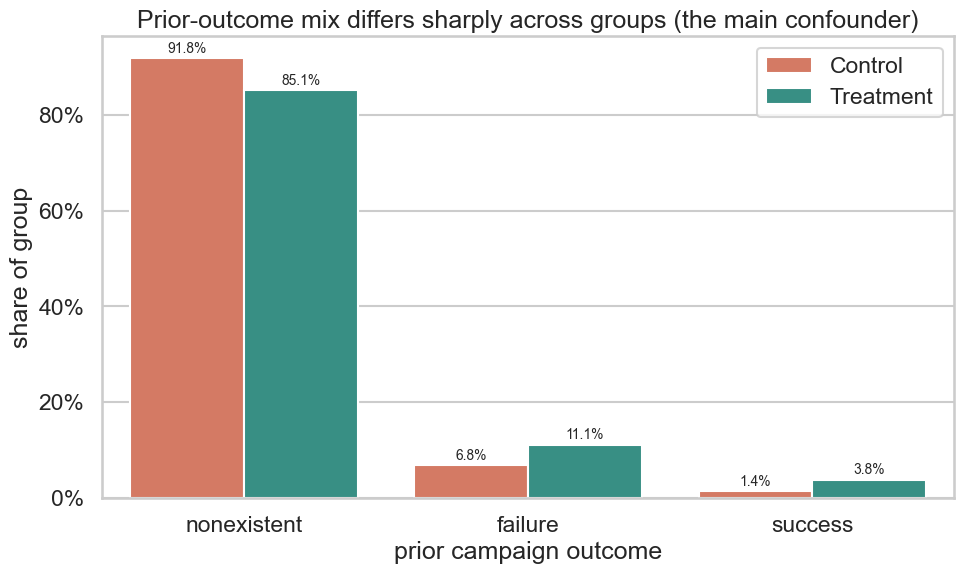

In [5]:
# the prior-campaign outcome differs sharply across the groups.
po_mix = (covars.groupby("arm")["prior_outcome"].value_counts(normalize=True)
          .rename("share").reset_index())
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=po_mix, x="prior_outcome", y="share", hue="arm",
            order=["nonexistent", "failure", "success"],
            palette={"Treatment": "#2a9d8f", "Control": "#e76f51"}, ax=ax)
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct))
ax.set_title("Prior-outcome mix differs sharply across groups (the main confounder)")
ax.set_xlabel("prior campaign outcome"); ax.set_ylabel("share of group")
for cont in ax.containers:
    ax.bar_label(cont, fmt=lambda v: f"{v:.1%}", fontsize=10, padding=2)
ax.legend(title="")
save(fig, "quasi_covariate_imbalance.png")
plt.show()

_Caption: demographics barely move, but **the prior-campaign outcome differs sharply**. The Treatment (1-3) group is **2.7x richer in previously-successful clients (3.78% vs 1.38%)** and lighter in never-contacted cold leads (85.1% vs 91.8%). The 4+ group is disproportionately **cold leads receiving many calls**, clients with no prior relationship who were always going to convert less. This is the Day-3 confounder (`prior_outcome=success`, about 65% conversion) showing up again: the contact-cap variable is entangled with prior engagement, so the naive lift is not the causal effect of a cap._

## Guardrail metrics across the two groups

In [6]:
# Guardrail metrics across the two groups (declared in notebook 03).
guard = client.query(f"""
    with j as (
      select case when o.n_contacts_this_campaign <= 3 then 'Treatment (1-3)' else 'Control (4+)' end as arm,
             o.n_contacts_this_campaign as nc, o.subscribed, m.job
      from `{MARTS}.mart_campaign_outcomes` o
      join `{MARTS}.mart_customers` m using (contact_id)
    )
    select arm,
           count(*) as n,
           countif(subscribed) as subs,
           sum(nc) as total_contacts,
           safe_divide(sum(nc), countif(subscribed)) as contacts_per_sub,
           avg(case when job in ('retired','management','student') then cast(subscribed as int64) end) as highvalue_subrate,
           avg(case when job = 'blue-collar' then nc end) as bluecollar_avg_contacts
    from j group by arm order by arm
""").to_dataframe().set_index("arm")
display(guard[["contacts_per_sub", "highvalue_subrate", "bluecollar_avg_contacts"]]
        .style.format({"contacts_per_sub": "{:.1f}", "highvalue_subrate": "{:.1%}",
                       "bluecollar_avg_contacts": "{:.2f}"}))
print("Read with care: 'better' guardrails in Treatment are themselves driven by "
      "selection (engaged clients convert fast AND have few contacts).")

C:\Users\PRASHANT\bank-campaign-causal-intelligence\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,contacts_per_sub,highvalue_subrate,bluecollar_avg_contacts
arm,,,
Control (4+),91.8,10.7%,6.66
Treatment (1-3),13.4,20.4%,1.65


Read with care: 'better' guardrails in Treatment are themselves driven by selection (engaged clients convert fast AND have few contacts).


_Caption: on paper every guardrail favours the cap, fewer contacts per subscription, higher high-value conversion, fewer blue-collar contacts. But these are the **same selection artifact** wearing different hats: clients who convert do so early, so they sit in Treatment by construction. The guardrails are reassuring only if the groups were exchangeable, and we just showed they are not._

## Back-of-envelope business impact: contact-cap policies

What would each cap have cost and saved on this campaign? Stated with **explicit bounds**, because the answer hinges on causation we have not yet established.

In [7]:
# Back-of-envelope business impact of a contact cap, from the exact contact
# distribution. Two bounds on subscriptions, stated explicitly:
#   conservative -> a subscriber needed ALL their contacts; cap loses any who
#                   subscribed beyond it (pessimistic about the cap).
#   optimistic   -> subscribers would have converted within the cap anyway
#                   (rate held constant; cap loses none).
dist = client.query(f"""
    select n_contacts_this_campaign as k, count(*) as n, countif(subscribed) as subs
    from `{MARTS}.mart_campaign_outcomes` group by k order by k
""").to_dataframe()
K = dist["k"].to_numpy(dtype=int)
N = dist["n"].to_numpy(dtype=int)
S = dist["subs"].to_numpy(dtype=int)
total_contacts = int((K * N).sum())
total_subs = int(S.sum())
total_clients = int(N.sum())

rows = []
for cap in [1, 2, 3, 4, 5, K.max()]:
    used = int(np.minimum(K, cap).dot(N))
    saved = total_contacts - used
    subs_cons = int(S[K <= cap].sum())            # conservative
    subs_opt = total_subs                          # optimistic upper bound
    rows.append({
        "cap": "unlimited" if cap == K.max() else str(cap),
        "contacts_used": used,
        "contacts_saved": saved,
        "pct_calls_saved": saved / total_contacts,
        "subs_retained_conservative": subs_cons,
        "subs_lost_conservative": total_subs - subs_cons,
        "subs_retained_optimistic": subs_opt,
    })
cap_tbl = pd.DataFrame(rows).set_index("cap")
display(cap_tbl.style.format({
    "contacts_used": "{:,}", "contacts_saved": "{:,}", "pct_calls_saved": "{:.1%}",
    "subs_retained_conservative": "{:,}", "subs_lost_conservative": "{:,}",
    "subs_retained_optimistic": "{:,}"}))

c3 = cap_tbl.loc["3"]
print(f"\nCap at 3: saves {c3['contacts_saved']:,} calls ({c3['pct_calls_saved']:.1%} of "
      f"{total_contacts:,}).")
print(f"  conservative: lose {c3['subs_lost_conservative']:,} of {total_subs:,} subscribers "
      f"({c3['subs_lost_conservative']/total_subs:.1%}).")
print(f"  optimistic:   lose 0 subscribers.")
print("The true number lives between these bounds -- and which end depends entirely "
      "on whether late contacts CAUSE conversions. That is the Day-5 question.")

C:\Users\PRASHANT\bank-campaign-causal-intelligence\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,contacts_used,contacts_saved,pct_calls_saved,subs_retained_conservative,subs_lost_conservative,subs_retained_optimistic
cap,,,,,,
1,"41,188","64,566",61.1%,"2,300","2,340","4,640"
2,"64,734","41,020",38.8%,"3,511","1,129","4,640"
3,"77,710","28,044",26.5%,"4,085",555,"4,640"
4,"85,345","20,409",19.3%,"4,334",306,"4,640"
5,"90,329","15,425",14.6%,"4,454",186,"4,640"
unlimited,"105,754",0,0.0%,"4,640",0,"4,640"



Cap at 3: saves 28,044.0 calls (26.5% of 105,754).
  conservative: lose 555.0 of 4,640 subscribers (12.0%).
  optimistic:   lose 0 subscribers.
The true number lives between these bounds -- and which end depends entirely on whether late contacts CAUSE conversions. That is the Day-5 question.


saved -> reports\figures\quasi_contact_cap_tradeoff.png


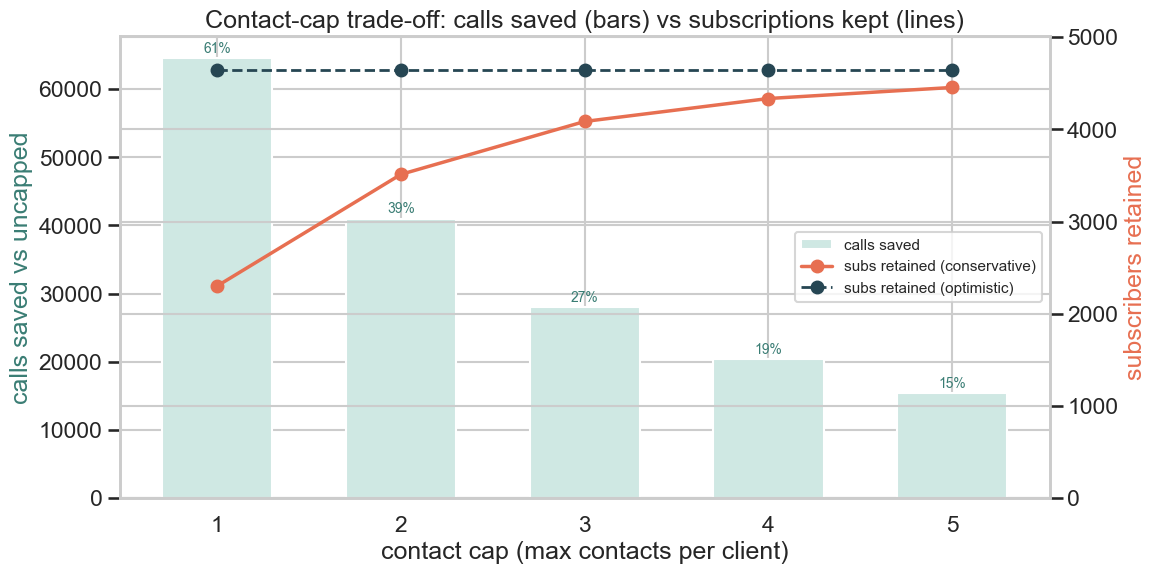

In [8]:
# The trade-off curve: calls saved vs subscriptions retained, across caps.
plot = cap_tbl.drop(index="unlimited").copy()
plot["x"] = plot.index.astype(int)
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(plot["x"], plot["contacts_saved"], color="#cfe8e3", width=0.6, label="calls saved")
ax1.set_xlabel("contact cap (max contacts per client)")
ax1.set_ylabel("calls saved vs uncapped", color="#3a7d74")
for x, v, pcts in zip(plot["x"], plot["contacts_saved"], plot["pct_calls_saved"]):
    ax1.text(x, v + 800, f"{pcts:.0%}", ha="center", fontsize=10, color="#3a7d74")

ax2 = ax1.twinx()
ax2.plot(plot["x"], plot["subs_retained_conservative"], marker="o", color="#e76f51",
         linewidth=2.5, label="subs retained (conservative)")
ax2.plot(plot["x"], plot["subs_retained_optimistic"], marker="o", linestyle="--",
         color="#264653", linewidth=2, label="subs retained (optimistic)")
ax2.set_ylabel("subscribers retained", color="#e76f51")
ax2.set_ylim(0, total_subs * 1.08)
ax1.set_title("Contact-cap trade-off: calls saved (bars) vs subscriptions kept (lines)")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=11)
save(fig, "quasi_contact_cap_tradeoff.png")
plt.show()

## Bottom line

The naive comparison says capping at 3 *lifts* subscription by 67% (12.2% vs 7.3%). **That number is not the causal effect of a cap.** The two groups are demonstrably not exchangeable, and the imbalance concentrates exactly where it does most damage: the **campaign-engagement covariates** (prior outcome p~1e-55, contact month p~1e-158, channel p~1e-31), not raw demographics (education is balanced). Contact count is a *consequence* of client engagement, not a randomized assignment, the 4+ group is full of cold leads who were always going to convert less, cap or no cap.

The resource case is real and large (capping at 3 saves ~26% of all calls); the subscription case is **bounded but unresolved**, somewhere between losing 12% of subscribers (if late contacts genuinely convert) and losing none (if they don't). **Day 5 quantifies exactly that confounding** and turns these bounds into an estimate.